In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



In [6]:
image_path = r"C:\ML_PROJECT\Deep_Learning\army-day.jpg"
img = Image.open(image_path)
img = img.resize((128,128))  


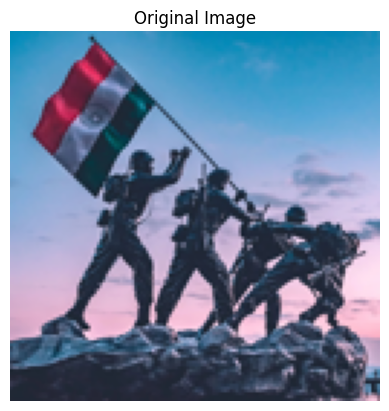

In [7]:
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [8]:

img_array = np.array(img)

print("Original Shape:", img_array.shape)

Original Shape: (128, 128, 3)


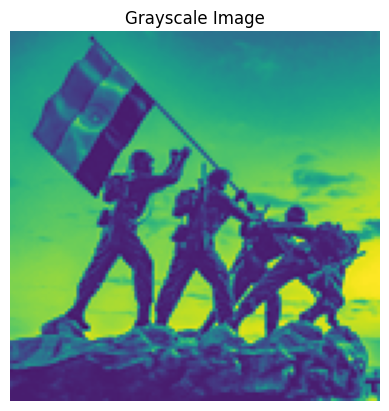

In [9]:
img_gray = np.mean(img_array, axis=2)

plt.figure()
plt.title("Grayscale Image")
plt.imshow(img_gray)
plt.axis("off")
plt.show()

In [10]:
def conv3d(image, kernel):
    d, h, w = image.shape
    kd, kh, kw = kernel.shape
    
    output = np.zeros((d-kd+1, h-kh+1, w-kw+1))
    
    for z in range(d-kd+1):
        for i in range(h-kh+1):
            for j in range(w-kw+1):
                region = image[z:z+kd, i:i+kh, j:j+kw]
                output[z,i,j] = np.sum(region * kernel)
                
    return output


In [16]:
depth = 3
img_3d = np.stack([img_gray]*depth)


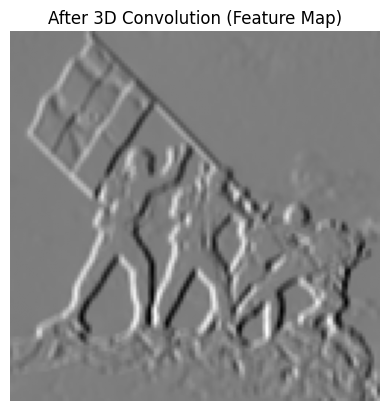

In [17]:
kernel_3d = np.array([
    [[1, 0, -1],
     [1, 0, -1],
     [1, 0, -1]],

    [[1, 0, -1],
     [1, 0, -1],
     [1, 0, -1]],

    [[1, 0, -1],
     [1, 0, -1],
     [1, 0, -1]]
])


conv_output = conv3d(img_3d, kernel_3d)


plt.figure()
plt.title("After 3D Convolution (Feature Map)")
plt.imshow(conv_output[0], cmap='gray') 
plt.axis("off")
plt.show()

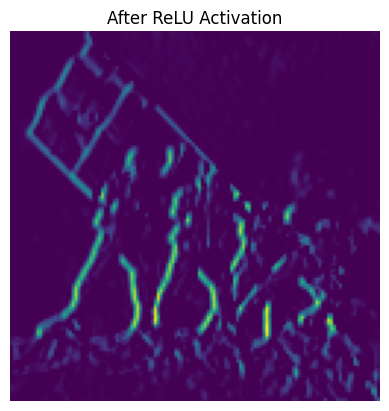

In [19]:
relu_output = np.maximum(0, conv_output)

plt.figure()
plt.title("After ReLU Activation")
plt.imshow(relu_output[0])
plt.axis("off")
plt.show()

In [20]:
gap_output = np.mean(relu_output)

print("Global Average Pooling Output:", gap_output)

Global Average Pooling Output: 74.00440917107584
